In [1]:
# Importing Libraries
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 1

In [8]:
df_DS_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Scientist')].copy()

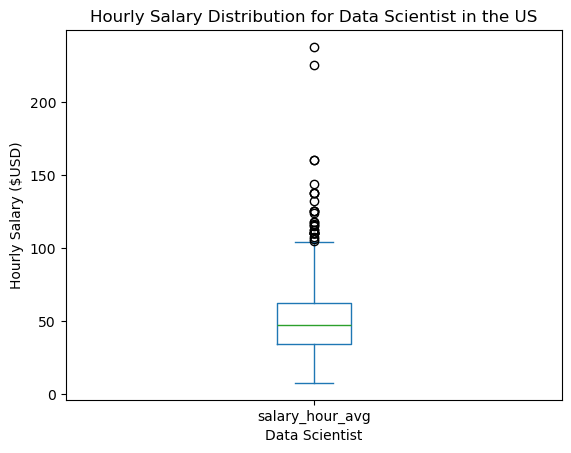

In [9]:
df_DS_US['salary_hour_avg'].plot(kind='box')
plt.xlabel('Data Scientist')
plt.ylabel('Hourly Salary ($USD)')
plt.title('Hourly Salary Distribution for Data Scientist in the US')
plt.show()

## 2

/var/folders/v2/fc7r9f5j4wv1rd0hxy17rqkr0000gn/T/ipykernel_12292/2310809812.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(list, labels=countries)


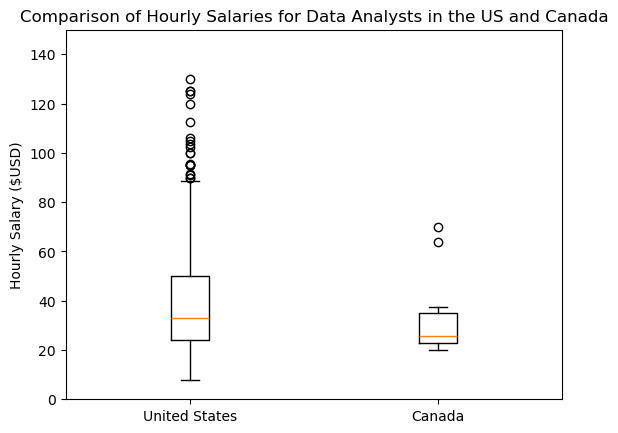

In [15]:
countries = ['United States', 'Canada']
df_filtered = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(countries))].dropna(subset=['salary_hour_avg']).copy()

list = [df_filtered[df_filtered['job_country'] == country]['salary_hour_avg'] for country in countries ]
plt.boxplot(list, labels=countries)
plt.ylabel('Hourly Salary ($USD)')
plt.ylim(0, 150)
plt.title('Comparison of Hourly Salaries for Data Analysts in the US and Canada')
plt.show()

## 3

In [28]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_filteredd = df[
    (df['job_title_short'].isin(job_titles)) &
    (df['job_country'] == 'Canada')
].dropna(subset=['salary_hour_avg']).copy()

job_list = [
    df_filteredd[df_filteredd['job_title_short'] == job]['salary_hour_avg']
    for job in job_titles
]

/var/folders/v2/fc7r9f5j4wv1rd0hxy17rqkr0000gn/T/ipykernel_12292/705451096.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(job_list, labels=job_titles)


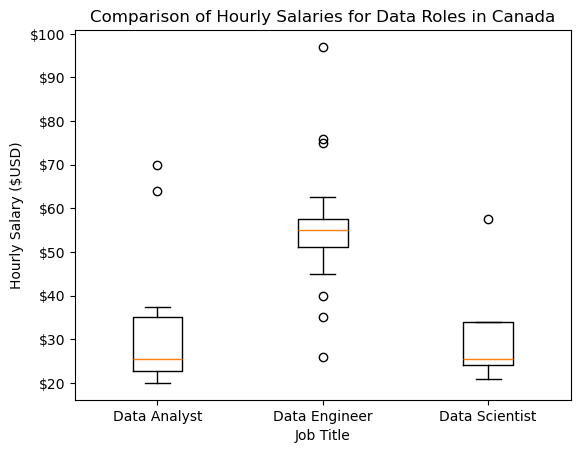

In [29]:
fig, ax = plt.subplots()
ax.boxplot(job_list, labels=job_titles)
ax.set_ylabel('Hourly Salary ($USD)')
ax.set_xlabel('Job Title') 
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y)}'))
ax.set_title('Comparison of Hourly Salaries for Data Roles in Canada')
plt.show()

In [24]:
job_list

[Series([], Name: salary_hour_avg, dtype: float64),
 Series([], Name: salary_hour_avg, dtype: float64),
 Series([], Name: salary_hour_avg, dtype: float64)]